In [ ]:
unimport re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/Drive')

Mounted at /content/Drive


In [ ]:
# =============================================================================
# SECCIÓN A & B: CONFIGURACIÓN, CARGA DE DATOS RAW Y EXPORTACIÓN
# =============================================================================
import re
import numpy as np
import pandas as pd
from pathlib import Path

# Folder containing all CSV files:
RAW_FOLDER = Path('/content/Drive/MyDrive/TIMESERIES/RawData')

# Folder where results will be saved (AHORA USANDO Results1)
PROJECT_DIR = Path('/content/Drive/MyDrive/TIMESERIES/Results1/')


START_DATE = "2018-12-12"
END_DATE   = "2026-03-27"
FREQ = "5D"

# Frecuencia angular para el modelo armónico de vegetación (coseno triplemente modulado)
# Asumiendo que el tiempo 't' estará en días y el ciclo es anual
OMEGA = 2 * np.pi / 365.25

print("Raw folder:", RAW_FOLDER)
print("Results folder:", PROJECT_DIR)
print(f"Frecuencia angular (Omega) configurada a: {OMEGA:.6f}\n")

# -----------------------------------------------------------------------------
# Funciones de carga de datos
# -----------------------------------------------------------------------------
def extract_date_from_filename(path):
    """Extrae YYYY-MM-DD desde el nombre del archivo."""
    match = re.search(r"\d{4}-\d{2}-\d{2}", path.name)
    if match is None:
        raise ValueError(f"No se encontró fecha en el archivo: {path.name}")
    return pd.to_datetime(match.group(0))

def load_one_csv(path):
    """Carga un CSV, limpia columnas y asigna pixel_id."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    date = extract_date_from_filename(path)
    df["date"] = date
    df["source_file"] = path.name

    possible_id_cols = ["pixel_id", "Pixel_ID", "id", "ID"]
    found_id = next((col for col in possible_id_cols if col in df.columns), None)

    if found_id is None:
        df["pixel_id"] = np.arange(len(df))
    else:
        df = df.rename(columns={found_id: "pixel_id"})

    return df

# -----------------------------------------------------------------------------
# Ejecución: Carga y concatenación
# -----------------------------------------------------------------------------
csv_files = sorted(RAW_FOLDER.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No se encontraron archivos CSV en {RAW_FOLDER}")

print(f"Se encontraron {len(csv_files)} archivos CSV. Iniciando carga...")

df_all = pd.concat([load_one_csv(path) for path in csv_files], ignore_index=True)

# Asegurar el formato datetime y ordenar cronológicamente por píxel
df_all["date"] = pd.to_datetime(df_all["date"])
df_all = df_all.sort_values(["pixel_id", "date"]).reset_index(drop=True)

print(f"Dimensión total del dataset raw: {df_all.shape}")

# -----------------------------------------------------------------------------
# Exportación de la data cruda a Results1
# -----------------------------------------------------------------------------
raw_export_path = PROJECT_DIR / "raw_satellite_timeseries.csv"
df_all.to_csv(raw_export_path, index=False)

print(f"Datos RAW exportados con éxito en:\n{raw_export_path}")

# Mostrar las primeras filas para verificar
df_all.head()


Raw folder: /content/Drive/MyDrive/TIMESERIES/RawData
Results folder: /content/Drive/MyDrive/TIMESERIES/Results1
Frecuencia angular (Omega) configurada a: 0.017202

Se encontraron 129 archivos CSV. Iniciando carga...
Dimensión total del dataset raw: (128341, 19)
Datos RAW exportados con éxito en:
/content/Drive/MyDrive/TIMESERIES/Results1/raw_satellite_timeseries.csv


,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,B9,BSI,CLOUD_PERCENTAGE,NDMI,NDVI,date,source_file,pixel_id
0,3004.0,3107.0,2578.0,2834.0,2972.0,3010.0,3265.0,3725.0,3961.0,3764.0,4130.0,5147.0,-0.037829,0,0.095619,0.111308,2018-12-12,dataset_satellite_raw_2018-12-12.csv,0
1,198.0,2660.0,1608.0,339.0,581.0,731.0,979.0,1472.0,1713.0,1876.0,2035.0,1722.0,0.209775,0,-0.172840,0.439202,2018-12-17,dataset_satellite_raw_2018-12-17.csv,0
2,243.0,2208.0,1355.0,359.0,485.0,595.0,810.0,1191.0,1387.0,1504.0,1618.0,1643.0,0.201457,0,-0.189655,0.433063,2018-12-22,dataset_satellite_raw_2018-12-22.csv,0
3,452.0,2207.0,1329.0,467.0,590.0,681.0,895.0,1273.0,1438.0,1558.0,1702.0,1566.0,0.175656,0,-0.172377,0.391693,2018-12-27,dataset_satellite_raw_2018-12-27.csv,0
4,305.0,2263.0,1382.0,399.0,554.0,674.0,873.0,1244.0,1439.0,1612.0,1678.0,1642.0,0.187146,0,-0.168000,0.410324,2019-01-01,dataset_satellite_raw_2019-01-01.csv,0


In [ ]:
# =============================================================================
# ANÁLISIS DE FECHAS Y DETECCIÓN DE VACÍOS (GAP-FILLING PREP)
# =============================================================================

# Obtener las fechas reales que tenemos en los datos crudos
actual_dates = pd.Series(df_all["date"].unique()).sort_values().reset_index(drop=True)

# Crear el rango de fechas esperado según nuestra frecuencia de 5 días (Sentinel-2)
expected_dates = pd.date_range(START_DATE, END_DATE, freq=FREQ)

# Incluir la fecha de fin (END_DATE) incluso si no cae exactamente en el múltiplo de 5 días
end_date_ts = pd.to_datetime(END_DATE)
if end_date_ts not in expected_dates:
    expected_dates = expected_dates.union(pd.DatetimeIndex([end_date_ts]))

# --- Reporte de Fechas ---
print("--- ANÁLISIS DE COBERTURA TEMPORAL ---")
print(f"Primera fecha real observada: {actual_dates.min()}")
print(f"Última fecha real observada:  {actual_dates.max()}")
print(f"Total de fechas reales:       {len(actual_dates)}\n")

print(f"Primera fecha esperada:       {expected_dates.min()}")
print(f"Última fecha esperada:        {expected_dates.max()}")
print(f"Total de fechas esperadas:    {len(expected_dates)}\n")

# Calcular qué fechas nos faltan (gaps) y si hay fechas extrañas
missing_dates = sorted(set(expected_dates) - set(actual_dates))
extra_dates = sorted(set(actual_dates) - set(expected_dates))

print(f"Fechas esperadas FALTANTES (Gaps a rellenar por el EKF): {len(missing_dates)}")
print(f"Fechas reales EXTRA (Fuera de la frecuencia): {len(extra_dates)}\n")

if len(missing_dates) > 0:
    print("Ejemplo de fechas faltantes:")
    for d in missing_dates[:5]:
        print(f"  - {d.strftime('%Y-%m-%d')}")

if len(extra_dates) > 0:
    print("\nEjemplo de fechas extra:")
    for d in extra_dates[:5]:
        print(f"  - {d.strftime('%Y-%m-%d')}")

--- ANÁLISIS DE COBERTURA TEMPORAL ---
Primera fecha real observada: 2018-12-12 00:00:00
Última fecha real observada:  2020-09-12 00:00:00
Total de fechas reales:       129

Primera fecha esperada:       2018-12-12 00:00:00
Última fecha esperada:        2026-03-27 00:00:00
Total de fechas esperadas:    534

Fechas esperadas FALTANTES (Gaps a rellenar por el EKF): 405
Fechas reales EXTRA (Fuera de la frecuencia): 0

Ejemplo de fechas faltantes:
  - 2020-09-17
  - 2020-09-22
  - 2020-09-27
  - 2020-10-02
  - 2020-10-07


In [ ]:
# =============================================================================
# C. PREPARACIÓN DE CARACTERÍSTICAS E ÍNDICES ESPECTRALES
# =============================================================================

BAND_COLS = [
    "B1", "B2", "B3", "B4", "B5", "B6", "B7",
    "B8", "B8A", "B9", "B11", "B12"
]

INDEX_COLS = ["NDVI", "NDMI", "BSI"]

def safe_divide(a, b):
    """Realiza una división segura para evitar errores de división por cero."""
    return np.where(np.abs(b) < 1e-12, np.nan, a / b)

def prepare_features(df):
    """
    Convierte a numérico, escala las bandas de Sentinel-2 y calcula
    los índices espectrales (NDVI, NDMI, BSI) si no están presentes.
    """
    df = df.copy()

    # 1. Convertir todas las columnas relevantes a numérico (forzando errores a NaN)
    for col in BAND_COLS + INDEX_COLS + ["CLOUD_PERCENTAGE"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 2. Escalar las bandas de Sentinel-2 si están en el rango 0-10000
    for col in BAND_COLS:
        if col in df.columns:
            if df[col].quantile(0.95) > 2:
                df[col] = df[col] / 10000.0

    # 3. Recalcular el NDVI si falta (Señal principal para el modelo armónico)
    if "NDVI" not in df.columns and {"B8", "B4"}.issubset(df.columns):
        df["NDVI"] = safe_divide(df["B8"] - df["B4"], df["B8"] + df["B4"])

    # 4. Recalcular el NDMI si falta
    if "NDMI" not in df.columns and {"B8", "B11"}.issubset(df.columns):
        df["NDMI"] = safe_divide(df["B8"] - df["B11"], df["B8"] + df["B11"])

    # 5. Recalcular el BSI (Índice de Suelo Desnudo) si falta
    if "BSI" not in df.columns and {"B11", "B4", "B8", "B2"}.issubset(df.columns):
        numerator = (df["B11"] + df["B4"]) - (df["B8"] + df["B2"])
        denominator = (df["B11"] + df["B4"]) + (df["B8"] + df["B2"])
        df["BSI"] = safe_divide(numerator, denominator)

    # 6. Limitar los índices a rangos físicos lógicos [-1, 1]
    for col in ["NDVI", "NDMI", "BSI"]:
        if col in df.columns:
            df[col] = df[col].clip(-1, 1)

    # 7. Asegurar que exista la columna de porcentaje de nubes para penalizar el ruido (Matriz R)
    if "CLOUD_PERCENTAGE" not in df.columns:
        df["CLOUD_PERCENTAGE"] = 0.0

    return df

# Aplicar la función al dataset
print("Procesando bandas y calculando índices fenológicos...")
df_all = prepare_features(df_all)

# Mostrar las primeras filas para verificar el procesamiento
df_all.head()

Procesando bandas y calculando índices fenológicos...


,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,B9,BSI,CLOUD_PERCENTAGE,NDMI,NDVI,date,source_file,pixel_id
0,0.3004,0.3107,0.2578,0.2834,0.2972,0.3010,0.3265,0.3725,0.3961,0.3764,0.4130,0.5147,-0.037829,0,0.095619,0.111308,2018-12-12,dataset_satellite_raw_2018-12-12.csv,0
1,0.0198,0.2660,0.1608,0.0339,0.0581,0.0731,0.0979,0.1472,0.1713,0.1876,0.2035,0.1722,0.209775,0,-0.172840,0.439202,2018-12-17,dataset_satellite_raw_2018-12-17.csv,0
2,0.0243,0.2208,0.1355,0.0359,0.0485,0.0595,0.0810,0.1191,0.1387,0.1504,0.1618,0.1643,0.201457,0,-0.189655,0.433063,2018-12-22,dataset_satellite_raw_2018-12-22.csv,0
3,0.0452,0.2207,0.1329,0.0467,0.0590,0.0681,0.0895,0.1273,0.1438,0.1558,0.1702,0.1566,0.175656,0,-0.172377,0.391693,2018-12-27,dataset_satellite_raw_2018-12-27.csv,0
4,0.0305,0.2263,0.1382,0.0399,0.0554,0.0674,0.0873,0.1244,0.1439,0.1612,0.1678,0.1642,0.187146,0,-0.168000,0.410324,2019-01-01,dataset_satellite_raw_2019-01-01.csv,0


In [ ]:
# =============================================================================
# C.2. CÁLCULO DEL PROXY DE BIOMASA (SEÑAL PARA EL MODELO ARMÓNICO)
# =============================================================================

def sigmoid(x):
    """Función de activación sigmoide para restringir valores al rango [0, 1]."""
    return 1.0 / (1.0 + np.exp(-x))

def add_biomass_proxy(df):
    """
    Calcula un proxy de biomasa fusionando NDVI, NDMI, BSI y reflectancia NIR.
    Este proxy puede usarse como la señal de entrada (observación 'y_t') para
    nuestro Filtro de Kalman con el modelo coseno triplemente modulado.
    """
    df = df.copy()

    # 1. Calcular NIRv (Reflectancia NIR de la vegetación) = NDVI * NIR
    if {"NDVI", "B8"}.issubset(df.columns):
        df["NIRv"] = df["NDVI"] * df["B8"]
    else:
        df["NIRv"] = np.nan

    # 2. Estandarización robusta del NIRv
    nirv_median = df["NIRv"].median()
    nirv_std = df["NIRv"].std()

    if pd.isna(nirv_std) or nirv_std == 0:
        df["NIRv_z"] = 0.0
    else:
        df["NIRv_z"] = (df["NIRv"] - nirv_median) / nirv_std

    # 3. Puntuación lineal combinando los índices fenológicos
    # Mayor NDVI, NDMI, NIRv_z -> más biomasa (impacto positivo)
    # Mayor BSI (Suelo Desnudo) -> menos biomasa (impacto negativo)
    linear_score = (
        2.0 * df["NDVI"].fillna(0)
        + 1.2 * df["NDMI"].fillna(0)
        - 1.0 * df["BSI"].fillna(0)
        + 0.4 * df["NIRv_z"].fillna(0)
    )

    # 4. Aplicar sigmoide para obtener el proxy final en el rango [0, 1]
    df["biomass_proxy"] = sigmoid(linear_score)

    return df

print("Calculando el Proxy de Biomasa consolidado...")
df_all = add_biomass_proxy(df_all)

# Mostrar un subconjunto de columnas para verificar el cálculo
cols_to_show = ["date", "pixel_id", "NDVI", "NDMI", "BSI", "NIRv", "biomass_proxy"]
df_all[cols_to_show].head()

Calculando el Proxy de Biomasa consolidado...


,date,pixel_id,NDVI,NDMI,BSI,NIRv,biomass_proxy
0,2018-12-12,0,0.111308,0.095619,-0.037829,0.041896,0.590429
1,2018-12-17,0,0.439202,-0.172840,0.209775,0.082394,0.655769
2,2018-12-22,0,0.433063,-0.189655,0.201457,0.065133,0.631396
3,2018-12-27,0,0.391693,-0.172377,0.175656,0.061026,0.618328
4,2019-01-01,0,0.410324,-0.168000,0.187146,0.066144,0.631310


In [ ]:
# =============================================================================
# C.3. EXPORTACIÓN DEL DATASET CONSOLIDADO (CON ÍNDICES Y PROXY)
# =============================================================================

# Definir la ruta de exportación usando el PROJECT_DIR (que apunta a Results1)
consolidated_path = PROJECT_DIR / "consolidated_satellite_timeseries_long.csv"

# Exportar el DataFrame completo sin el índice
df_all.to_csv(consolidated_path, index=False)

print(f"Dataset consolidado guardado exitosamente en:\n{consolidated_path}")

Dataset consolidado guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/consolidated_satellite_timeseries_long.csv


In [ ]:
# =============================================================================
# C.4. AGRUPACIÓN ESPACIAL Y RELLENO DE FECHAS (PREPARACIÓN PARA EKF)
# =============================================================================

# Definimos las columnas de observación y auxiliares
OBS_COLS = ["biomass_proxy", "NDVI", "NDMI", "BSI"]
AUX_COLS = ["CLOUD_PERCENTAGE"]

# Filtrar solo las columnas que realmente existen en nuestro DataFrame
available_cols = [c for c in OBS_COLS + AUX_COLS if c in df_all.columns]

print("Calculando la media espacial y rellenando fechas faltantes (gaps)...")

# Agrupar por fecha (media espacial de toda la reserva) y reindexar
ts_mean = (
    df_all
    .groupby("date")[available_cols]
    .mean()
    .reindex(expected_dates) # <-- ¡ESTE ES EL TRUCO DEL GAP-FILLING! Crea filas con NaN en los días sin satélite
)

# Nombrar el índice correctamente y convertirlo en columna
ts_mean.index.name = "date"
ts_mean = ts_mean.reset_index()

# Mostrar las primeras filas. Los días sin datos originales aparecerán como NaN
ts_mean.head()

Calculando la media espacial y rellenando fechas faltantes (gaps)...


,date,biomass_proxy,NDVI,NDMI,BSI,CLOUD_PERCENTAGE
0,2018-12-12,0.689210,0.274964,0.126197,-0.040577,0.0
1,2018-12-17,0.673330,0.269522,0.087274,-0.025533,0.0
2,2018-12-22,0.745450,0.441324,0.072608,-0.025746,0.0
3,2018-12-27,0.712780,0.366286,0.057137,-0.020042,0.0
4,2019-01-01,0.759427,0.468921,0.046942,-0.005485,0.0


In [ ]:
# =============================================================================
# C.5. EXPORTAR SERIE TEMPORAL MEDIA ESPACIAL (CON GAP-FILLING)
# =============================================================================

# Definir la ruta de exportación usando PROJECT_DIR (que apunta a Results1)
mean_path = PROJECT_DIR / "mean_5day_timeseries_for_ekf.csv"

# Guardar el DataFrame a un archivo CSV sin incluir el índice
ts_mean.to_csv(mean_path, index=False)

print(f"Serie temporal media (preparada para el EKF) guardada exitosamente en:\n{mean_path}")

Serie temporal media (preparada para el EKF) guardada exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/mean_5day_timeseries_for_ekf.csv


In [ ]:
# =============================================================================
# D. DEFINICIÓN MATEMÁTICA DEL MODELO EKF ARMÓNICO
# =============================================================================
# Ecuación del modelo: y_t = mu_t + alpha_t * cos(OMEGA * t + phi_t) + v_t
# Vector de estado latente: x = [mu_t, alpha_t, phi_t]^T

def f_state(x):
    """
    Modelo de Transición de Estado (Proceso No Lineal).

    x[0] = Nivel Medio (mu)
    x[1] = Amplitud (alpha)
    x[2] = Fase (phi)

    Asumimos que los parámetros fenológicos cambian muy lentamente (Random Walk).
    Por lo tanto, la predicción a priori es simplemente el estado anterior.
    """
    return x.copy()

def jacobian_f(x):
    """
    Jacobiana de f_state.
    Al ser un Random Walk (x_next = x), la derivada de cada variable respecto
    a sí misma es 1, y respecto a las demás es 0.
    Retorna una matriz Identidad de 3x3.
    """
    return np.eye(3)

def h_obs(x, day_t):
    """
    Modelo de Observación No Lineal.
    Mapea el estado latente [mu, alpha, phi] a la medición observada por
    el satélite (ej. el biomass_proxy o el NDVI) en un día específico.
    """
    mu, alpha, phi = x

    # y_t = mu + alpha * cos(omega * t + phi)
    return mu + alpha * np.np.cos(OMEGA * day_t + phi)

def jacobian_h(x, day_t):
    """
    Jacobiana de h_obs.
    Calcula las derivadas parciales de la función coseno triplemente modulada
    con respecto a mu, alpha y phi.
    """
    mu, alpha, phi = x
    H = np.zeros((1, 3))

    # 1. Derivada respecto a mu (Nivel Medio)
    # d/d_mu [mu + alpha * cos(wt + phi)] = 1.0
    H[0, 0] = 1.0

    # 2. Derivada respecto a alpha (Amplitud)
    # d/d_alpha [mu + alpha * cos(wt + phi)] = cos(wt + phi)
    H[0, 1] = np.cos(OMEGA * day_t + phi)

    # 3. Derivada respecto a phi (Fase)
    # d/d_phi [mu + alpha * cos(wt + phi)] = -alpha * sin(wt + phi)
    H[0, 2] = -alpha * np.sin(OMEGA * day_t + phi)

    return H

In [ ]:
def h_obs(x, day_t):
    """
    Modelo de Observación No Lineal.
    Mapea el estado latente [mu, alpha, phi] a la medición observada por
    el satélite (ej. el biomass_proxy o el NDVI) en un día específico.
    """
    mu, alpha, phi = x

    # y_t = mu + alpha * cos(omega * t + phi)
    return mu + alpha * np.cos(OMEGA * day_t + phi)

# =============================================================================
# D.2. BUCLE PRINCIPAL DEL FILTRO DE KALMAN EXTENDIDO ARMÓNICO
# =============================================================================

def run_harmonic_ekf(ts, target_var="biomass_proxy"):
    """
    Ejecuta el EKF armónico sobre una serie temporal para rastrear el ciclo
    estacional de una variable objetivo (ej. biomass_proxy o NDVI).
    """
    # Asegurarnos de que está ordenada cronológicamente
    ts = ts.copy().sort_values("date").reset_index(drop=True)

    # Extraer la variable observada (Z)
    Z = ts[target_var].to_numpy(dtype=float)

    # Extraer porcentaje de nubes para escalar el ruido (R_t)
    if "CLOUD_PERCENTAGE" in ts.columns:
        cloud = ts["CLOUD_PERCENTAGE"].fillna(0).to_numpy(dtype=float)
    else:
        cloud = np.zeros(len(ts))

    start_time = pd.to_datetime(START_DATE)

    # 1. Estado inicial: [mu, alpha, phi]
    # Asumimos valores biológicos típicos: media ~0.5, amplitud ~0.2, fase ~0.0
    x = np.array([0.5, 0.2, 0.0], dtype=float)

    # 2. Covarianza inicial (P): Qué tan incierto es nuestro estado inicial
    P = np.diag([0.1, 0.1, np.pi])

    # 3. Ruido del proceso (Q): Cuánto permitimos que mu, alpha y phi muten en el tiempo
    Q = np.diag([1e-4, 1e-4, 1e-4])

    # 4. Ruido base de observación (R_base)
    R_base = np.array([[0.015]]) # Matriz 1x1 porque ahora observamos 1 variable

    results = []

    for t in range(len(ts)):
        date_t = ts.loc[t, "date"]
        day_t = (date_t - start_time).days  # Día 't' para evaluar la onda armónica
        z_t = Z[t]

        # --- FASE DE PREDICCIÓN (A PRIORI) ---
        F = jacobian_f(x)
        x_pred = f_state(x)
        P_pred = F @ P @ F.T + Q

        # --- FASE DE ACTUALIZACIÓN (A POSTERIORI) ---
        valid = np.isfinite(z_t)

        # Factor penalizador por nubosidad
        cloud_factor = 1.0 + (cloud[t] / 20.0)
        R_t = R_base * cloud_factor

        if valid:
            H_t = jacobian_h(x_pred, day_t)         # Matriz 1x3
            h_val = h_obs(x_pred, day_t)            # Predicción de la señal pura (escalar)
            innovation = np.array([[z_t - h_val]])  # Matriz 1x1

            # Ganancia de Kalman (K)
            S = H_t @ P_pred @ H_t.T + R_t
            K = P_pred @ H_t.T @ np.linalg.inv(S)   # K será 3x1

            # Actualizar el estado
            x = x_pred + (K @ innovation).flatten()

            # Actualizar covarianza (Usando la Forma de Joseph por estabilidad matemática)
            I = np.eye(len(x))
            P = (I - K @ H_t) @ P_pred @ (I - K @ H_t).T + K @ R_t @ K.T
        else:
            # GAP-FILLING: Si es NaN (ej. sin datos), usamos directamente la predicción
            x = x_pred
            P = P_pred

        # --- RESTRICCIONES BIOLÓGICAS REALISTAS ---
        # mu (Nivel medio) debe estar contenido en el rango físico [0, 1]
        x[0] = np.clip(x[0], 0.0, 1.0)
        # alpha (Amplitud) no debería ser negativa ni exageradamente grande
        x[1] = np.clip(x[1], 0.0, 0.5)
        # phi (Fase) fluye libremente, pero se acota por naturaleza circular

        # Calcular la señal armónica reconstruida con el estado ajustado
        signal_filtered = h_obs(x, day_t)

        results.append({
            "date": date_t,
            f"{target_var}_observed": z_t,
            "signal_filtered": signal_filtered,
            "mu_filtered": x[0],
            "alpha_filtered": x[1],
            "phi_filtered": x[2],
            "var_mu": P[0, 0],
            "var_alpha": P[1, 1],
            "var_phi": P[2, 2],
            "CLOUD_PERCENTAGE": cloud[t]
        })

    return pd.DataFrame(results)

# -----------------------------------------------------------------------------
# EJECUCIÓN DE PRUEBA SOBRE LA SERIE TEMPORAL MEDIA (ts_mean)
# -----------------------------------------------------------------------------
print("Ejecutando el EKF Armónico sobre la serie temporal espacial media...")

# Llamamos a la función usando el ts_mean generado en el paso anterior
ekf_mean_results = run_harmonic_ekf(ts_mean, target_var="biomass_proxy")

ekf_mean_results.head(10)


Ejecutando el EKF Armónico sobre la serie temporal espacial media...


,date,biomass_proxy_observed,signal_filtered,mu_filtered,alpha_filtered,phi_filtered,var_mu,var_alpha,var_phi,CLOUD_PERCENTAGE
0,2018-12-12,0.689210,0.689962,0.494981,0.194981,0.000000,0.053539,0.053539,3.141693,0.0
1,2018-12-17,0.673330,0.681225,0.491134,0.191331,0.027926,0.051886,0.052060,3.049431,0.0
2,2018-12-22,0.745450,0.700050,0.502415,0.197819,-0.215143,0.051270,0.051924,2.717177,0.0
3,2018-12-27,0.712780,0.703429,0.503994,0.199784,-0.198969,0.051055,0.051535,2.684207,0.0
4,2019-01-01,0.759427,0.713972,0.509680,0.204447,-0.305081,0.050966,0.051508,2.618409,0.0
5,2019-01-06,0.611630,0.692462,0.501286,0.196182,-0.203666,0.050938,0.051484,2.599800,0.0
6,2019-01-11,0.772440,0.699696,0.510025,0.190460,-0.607107,0.050799,0.051482,2.091464,0.0
7,2019-01-16,0.711007,0.702726,0.510999,0.191792,-0.575911,0.050734,0.051273,1.922175,0.0
8,2019-01-21,0.736364,0.706522,0.512984,0.194820,-0.573316,0.050777,0.051240,1.922178,0.0
9,2019-01-26,0.670364,0.698208,0.511069,0.193733,-0.512454,0.050819,0.051321,1.863468,0.0


In [ ]:
# =============================================================================
# E. EJECUCIÓN Y EXPORTACIÓN DEL EKF SOBRE LA SERIE ESPACIAL MEDIA
# =============================================================================

print("Iniciando el filtrado armónico sobre la serie temporal media...")

# Ejecutamos el modelo armónico sobre el ts_mean, rastreando el 'biomass_proxy'
ekf_mean = run_harmonic_ekf(ts_mean, target_var="biomass_proxy")

# Definir la ruta de guardado (utilizando PROJECT_DIR que apunta a Results1)
ekf_mean_path = PROJECT_DIR / "ekf_harmonic_filtered_mean_timeseries.csv"

# Guardar los resultados en un archivo CSV
ekf_mean.to_csv(ekf_mean_path, index=False)

print(f"Resultados del Filtro de Kalman (Media Espacial) guardados en:\n{ekf_mean_path}\n")

# Mostrar las primeras filas para verificar las estimaciones latentes (mu, alpha, phi)
ekf_mean.head()

Iniciando el filtrado armónico sobre la serie temporal media...
Resultados del Filtro de Kalman (Media Espacial) guardados en:
/content/Drive/MyDrive/TIMESERIES/Results1/ekf_harmonic_filtered_mean_timeseries.csv



,date,biomass_proxy_observed,signal_filtered,mu_filtered,alpha_filtered,phi_filtered,var_mu,var_alpha,var_phi,CLOUD_PERCENTAGE
0,2018-12-12,0.689210,0.689962,0.494981,0.194981,0.000000,0.053539,0.053539,3.141693,0.0
1,2018-12-17,0.673330,0.681225,0.491134,0.191331,0.027926,0.051886,0.052060,3.049431,0.0
2,2018-12-22,0.745450,0.700050,0.502415,0.197819,-0.215143,0.051270,0.051924,2.717177,0.0
3,2018-12-27,0.712780,0.703429,0.503994,0.199784,-0.198969,0.051055,0.051535,2.684207,0.0
4,2019-01-01,0.759427,0.713972,0.509680,0.204447,-0.305081,0.050966,0.051508,2.618409,0.0


In [ ]:
#################################
#################################
#################################

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1434/134580281.py:21: SyntaxWarning: invalid escape sequence '\m'
  label="Tendencia Media ($\mu_t$)",


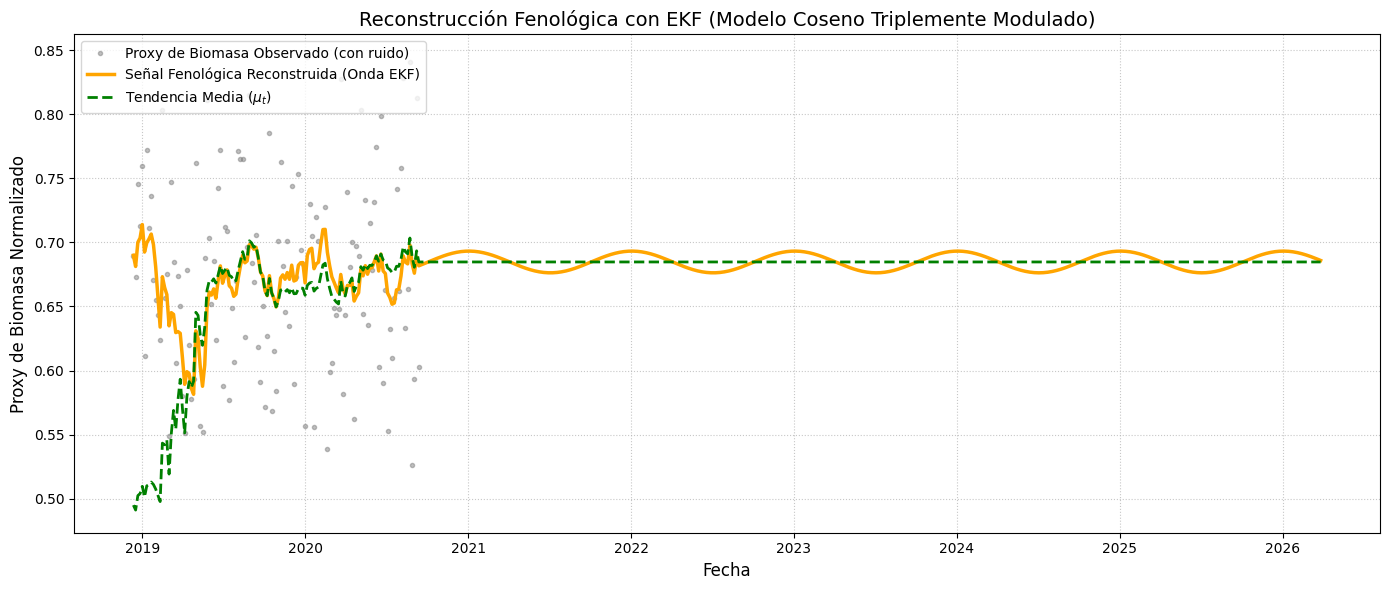

Gráfico guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/ekf_harmonic_biomass_filtered.png


In [ ]:
# =============================================================================
# F. VISUALIZACIÓN DE RESULTADOS: FILTRADO ARMÓNICO
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 1. Observaciones crudas (con ruido y gaps por nubes)
# Usamos un diagrama de dispersión (puntos) para las observaciones para que se noten los vacíos
plt.plot(ekf_mean["date"], ekf_mean["biomass_proxy_observed"],
         label="Proxy de Biomasa Observado (con ruido)",
         alpha=0.5, color="gray", marker=".", linestyle="none")

# 2. Señal filtrada (Curva armónica reconstruida - Gap Filling)
plt.plot(ekf_mean["date"], ekf_mean["signal_filtered"],
         label="Señal Fenológica Reconstruida (Onda EKF)",
         linewidth=2.5, color="orange")

# 3. Tendencia media (\mu_t) extraída por el filtro
plt.plot(ekf_mean["date"], ekf_mean["mu_filtered"],
         label="Tendencia Media ($\mu_t$)",
         linestyle="--", linewidth=2, color="green")

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Proxy de Biomasa Normalizado", fontsize=12)
plt.title("Reconstrucción Fenológica con EKF (Modelo Coseno Triplemente Modulado)", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la imagen en el directorio configurado (Results1)
fig_path = PROJECT_DIR / "ekf_harmonic_biomass_filtered.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico guardado exitosamente en:\n{fig_path}")

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1434/1020796912.py:25: SyntaxWarning: invalid escape sequence '\m'
  label="Tendencia Media ($\mu_t$)",


Ejecutando el EKF Armónico para rastrear el NDVI...


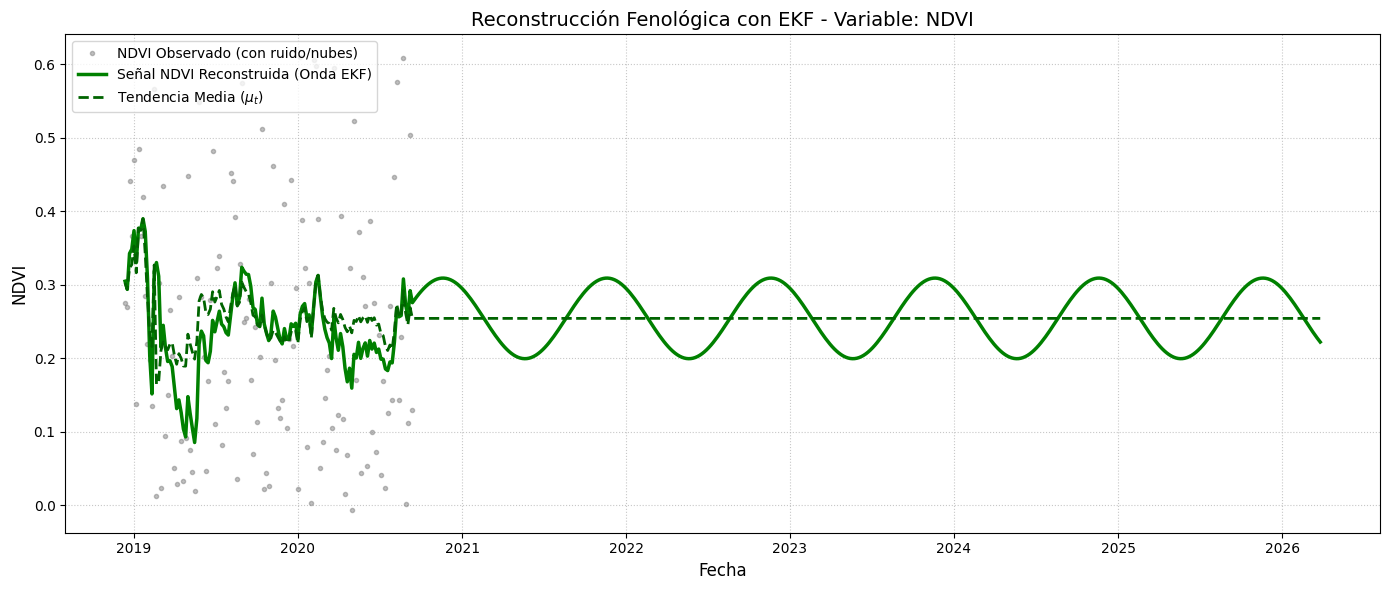

Gráfico de NDVI guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/ekf_harmonic_ndvi_filtered.png


In [ ]:
# =============================================================================
# F.2. VISUALIZACIÓN DE RESULTADOS: FILTRADO ARMÓNICO PARA NDVI
# =============================================================================
import matplotlib.pyplot as plt

# 1. Ejecutar el filtro específicamente para la variable NDVI
print("Ejecutando el EKF Armónico para rastrear el NDVI...")
ekf_mean_ndvi = run_harmonic_ekf(ts_mean, target_var="NDVI")

# 2. Configurar la figura
plt.figure(figsize=(14, 6))

# Observaciones crudas de NDVI (mostradas como puntos para resaltar los gaps)
plt.plot(ekf_mean_ndvi["date"], ekf_mean_ndvi["NDVI_observed"],
         label="NDVI Observado (con ruido/nubes)",
         alpha=0.5, color="gray", marker=".", linestyle="none")

# Señal armónica filtrada (Gap-filling)
plt.plot(ekf_mean_ndvi["date"], ekf_mean_ndvi["signal_filtered"],
         label="Señal NDVI Reconstruida (Onda EKF)",
         linewidth=2.5, color="green")

# Tendencia media de NDVI extraída por el filtro
plt.plot(ekf_mean_ndvi["date"], ekf_mean_ndvi["mu_filtered"],
         label="Tendencia Media ($\mu_t$)",
         linestyle="--", linewidth=2, color="darkgreen")

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("NDVI", fontsize=12)
plt.title("Reconstrucción Fenológica con EKF - Variable: NDVI", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la imagen en el directorio configurado (Results1)
fig_path = PROJECT_DIR / "ekf_harmonic_ndvi_filtered.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico de NDVI guardado exitosamente en:\n{fig_path}")

In [ ]:
# =============================================================================
# G. EJECUCIÓN DEL EKF ARMÓNICO POR CLASE DE COBERTURA (SI EXISTE)
# =============================================================================

if "Class" in df_all.columns:
    print("Columna 'Class' encontrada. Ejecutando EKF Armónico por clase...")
    class_results = []

    for class_value, df_class in df_all.groupby("Class"):
        # 1. Promedio espacial y reindexación (Gap-filling) específico para esta clase
        ts_class = (
            df_class
            .groupby("date")[available_cols]
            .mean()
            .reindex(expected_dates)
        )

        ts_class.index.name = "date"
        ts_class = ts_class.reset_index()

        # 2. Ejecutar el Filtro de Kalman Armónico para esta clase
        # Rastreamos el proxy de biomasa, pero puedes cambiarlo a "NDVI" si prefieres
        ekf_class = run_harmonic_ekf(ts_class, target_var="biomass_proxy")

        # Añadir la etiqueta de la clase a los resultados
        ekf_class["Class"] = class_value

        class_results.append(ekf_class)

    # 3. Unir todos los resultados de las diferentes clases
    ekf_by_class = pd.concat(class_results, ignore_index=True)

    # 4. Exportar a la carpeta Results1
    class_path = PROJECT_DIR / "ekf_harmonic_filtered_by_class.csv"
    ekf_by_class.to_csv(class_path, index=False)

    print(f"Resultados del EKF por clase guardados exitosamente en:\n{class_path}")

else:
    print("No se encontró la columna 'Class' en el dataset. Saltando la ejecución por clases.")

No se encontró la columna 'Class' en el dataset. Saltando la ejecución por clases.


In [ ]:
# =============================================================================
# H. EJECUCIÓN DEL EKF ARMÓNICO PÍXEL POR PÍXEL
# =============================================================================

RUN_PIXEL_EKF = True

if RUN_PIXEL_EKF:
    print("Iniciando la ejecución del EKF Armónico píxel por píxel (esto puede tomar un tiempo)...")
    pixel_results = []

    # Iterar sobre cada píxel independiente en la reserva
    for pixel_id, df_pixel in df_all.groupby("pixel_id"):

        # 1. Relleno de vacíos (Gap-filling) a nivel de píxel individual
        ts_pixel = (
            df_pixel
            .set_index("date")[available_cols]
            .reindex(expected_dates)
        )

        ts_pixel.index.name = "date"
        ts_pixel = ts_pixel.reset_index()

        # 2. Ejecutar el Filtro de Kalman Armónico para este píxel
        # Seguimos rastreando el proxy de biomasa como variable objetivo
        ekf_pixel = run_harmonic_ekf(ts_pixel, target_var="biomass_proxy")

        # 3. Asignar el ID del píxel a sus resultados correspondientes
        ekf_pixel["pixel_id"] = pixel_id

        pixel_results.append(ekf_pixel)

    # 4. Unir todos los resultados individuales en un solo DataFrame gigante
    ekf_by_pixel = pd.concat(pixel_results, ignore_index=True)

    # 5. Exportar a la carpeta configurada (Results1)
    pixel_path = PROJECT_DIR / "ekf_harmonic_filtered_by_pixel.csv"
    ekf_by_pixel.to_csv(pixel_path, index=False)

    print(f"Resultados del EKF Armónico a nivel de píxel guardados exitosamente en:\n{pixel_path}")

else:
    print("La ejecución por píxel está deshabilitada (RUN_PIXEL_EKF = False).")

Iniciando la ejecución del EKF Armónico píxel por píxel (esto puede tomar un tiempo)...
Resultados del EKF Armónico a nivel de píxel guardados exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/ekf_harmonic_filtered_by_pixel.csv


dividing the set


In [ ]:
# =============================================================================
# I. DIVISIÓN TEMPORAL: ENTRENAMIENTO (TRAIN) Y VALIDACIÓN (VAL)
# =============================================================================
import numpy as np
import pandas as pd

print("Calculando la división temporal 80/20 (Train/Validation)...")

# Asegurarnos de que el directorio del proyecto exista (apuntando a Results1)
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Extraer las fechas únicas disponibles en el dataset consolidado y ordenarlas
all_dates = pd.Series(df_all["date"].unique()).sort_values().reset_index(drop=True)

# Calcular el índice de corte para el 80% de entrenamiento y 20% de validación
split_index = int(len(all_dates) * 0.80)

# Definir las fechas límite
TRAIN_END_DATE = all_dates.iloc[split_index - 1]
VAL_START_DATE = all_dates.iloc[split_index]

print(f"Total de fechas únicas: {len(all_dates)}")
print(f"Fin de entrenamiento (Train):  {TRAIN_END_DATE.strftime('%Y-%m-%d')}")
print(f"Inicio de validación (Val):    {VAL_START_DATE.strftime('%Y-%m-%d')}\n")

# Asignar la etiqueta de conjunto ("train" o "validation") a cada fila de df_all
df_all["set"] = np.where(df_all["date"] <= TRAIN_END_DATE, "train", "validation")

# Mostrar un resumen para verificar que la división se aplicó correctamente
print("Primeras fechas (Train):")
print(df_all[["date", "set"]].drop_duplicates().head())

print("\nÚltimas fechas (Validation):")
print(df_all[["date", "set"]].drop_duplicates().tail())

Calculando la división temporal 80/20 (Train/Validation)...
Total de fechas únicas: 129
Fin de entrenamiento (Train):  2020-05-05
Inicio de validación (Val):    2020-05-10

Primeras fechas (Train):
        date    set
0 2018-12-12  train
1 2018-12-17  train
2 2018-12-22  train
3 2018-12-27  train
4 2019-01-01  train

Últimas fechas (Validation):
          date         set
124 2020-08-23  validation
125 2020-08-28  validation
126 2020-09-02  validation
127 2020-09-07  validation
128 2020-09-12  validation


In [ ]:
# =============================================================================
# I.2. EXPORTAR DATASET CON LA DIVISIÓN TRAIN/VALIDATION
# =============================================================================

# Definir la ruta de exportación (utilizando PROJECT_DIR que apunta a Results1)
split_path = PROJECT_DIR / "consolidated_dataset_with_train_validation_split.csv"

# Guardar el DataFrame completo con la nueva etiqueta de conjunto
df_all.to_csv(split_path, index=False)

print(f"Dataset con división Train/Validation guardado exitosamente en:\n{split_path}")

Dataset con división Train/Validation guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/consolidated_dataset_with_train_validation_split.csv


In [ ]:
# =============================================================================
# J. EKF ARMÓNICO CON CÁLCULO DE ERRORES (TRAIN / VALIDATION)
# =============================================================================

def run_harmonic_ekf_train_validation(ts, train_end_date, target_var="biomass_proxy", update_during_validation=True):
    """
    Ejecuta el EKF armónico sobre una serie temporal calculando errores de predicción.

    Parámetros
    ----------
    ts : DataFrame
        Debe contener 'date', la variable objetivo (ej. 'biomass_proxy') y 'CLOUD_PERCENTAGE'.
    train_end_date : Timestamp
        Última fecha utilizada como conjunto de entrenamiento.
    update_during_validation : bool
        True  -> Validación un-paso-adelante (One-step-ahead).
                 Calcula el error de predicción y LUEGO se actualiza con la observación.
        False -> Pronóstico puro (Pure forecast).
                 Una vez iniciada la validación, el modelo DEJA de actualizarse y
                 solo proyecta la onda armónica hacia el futuro.

    Retorna
    -------
    DataFrame con los estados filtrados, señal reconstruida y errores de predicción.
    """

    ts = ts.copy().sort_values("date").reset_index(drop=True)

    # Extraer la variable observada (Vector 1D)
    Z = ts[target_var].to_numpy(dtype=float)

    if "CLOUD_PERCENTAGE" in ts.columns:
        cloud = ts["CLOUD_PERCENTAGE"].fillna(0).to_numpy(dtype=float)
    else:
        cloud = np.zeros(len(ts))

    start_time = pd.to_datetime(START_DATE)

    # 1. Estado inicial [mu, alpha, phi]
    x = np.array([0.5, 0.2, 0.0], dtype=float)

    # 2. Covarianza inicial (P)
    P = np.diag([0.1, 0.1, np.pi])

    # 3. Ruido del proceso (Q)
    Q = np.diag([1e-4, 1e-4, 1e-4])

    # 4. Ruido de observación base (R_base)
    R_base = np.array([[0.015]])

    results = []

    for t in range(len(ts)):
        date_t = pd.to_datetime(ts.loc[t, "date"])
        day_t = (date_t - start_time).days
        z_t = Z[t]

        current_set = "train" if date_t <= train_end_date else "validation"

        # --------------------------
        # ETAPA DE PREDICCIÓN (A PRIORI)
        # --------------------------
        F = jacobian_f(x)
        x_pred = f_state(x)
        P_pred = F @ P @ F.T + Q

        # Predicción pura de la señal usando la onda armónica actual
        z_pred = h_obs(x_pred, day_t)

        # Error de predicción ANTES de corregir (Solo si tenemos una observación válida)
        valid = np.isfinite(z_t)
        prediction_error = z_t - z_pred if valid else np.nan

        # --------------------------
        # ETAPA DE CORRECCIÓN / ACTUALIZACIÓN
        # --------------------------
        cloud_factor = 1.0 + cloud[t] / 20.0
        R_t = R_base * cloud_factor

        # Decidir si el filtro tiene permitido aprender de este dato
        should_update = (
            valid
            and (current_set == "train" or update_during_validation)
        )

        if should_update:
            H_t = jacobian_h(x_pred, day_t)
            h_val = h_obs(x_pred, day_t)
            innovation = np.array([[z_t - h_val]])

            S = H_t @ P_pred @ H_t.T + R_t
            K = P_pred @ H_t.T @ np.linalg.inv(S)

            x = x_pred + (K @ innovation).flatten()

            I = np.eye(len(x))
            P = (I - K @ H_t) @ P_pred @ (I - K @ H_t).T + K @ R_t @ K.T

        else:
            # Si no hay datos, o estamos en modo "Pronóstico Puro", nos quedamos con la predicción
            x = x_pred
            P = P_pred

        # --------------------------
        # RESTRICCIONES FÍSICAS
        # --------------------------
        x[0] = np.clip(x[0], 0.0, 1.0) # Nivel medio (mu)
        x[1] = np.clip(x[1], 0.0, 0.5) # Amplitud (alpha)

        # Señal final después del filtro
        z_filt = h_obs(x, day_t)
        filtered_error = z_t - z_filt if valid else np.nan

        results.append({
            "date": date_t,
            "set": current_set,

            # Observación real
            f"{target_var}_observed": z_t,

            # Predicción (La onda adivinando el futuro)
            f"{target_var}_predicted": z_pred,

            # Filtrado (La onda ajustada a la realidad)
            f"{target_var}_filtered": z_filt,

            # Parámetros latentes aprendidos
            "mu_filtered": x[0],
            "alpha_filtered": x[1],
            "phi_filtered": x[2],

            # Errores
            "error_pred": prediction_error,
            "error_filt": filtered_error,

            # Varianzas
            "var_mu": P[0, 0],
            "var_alpha": P[1, 1],
            "var_phi": P[2, 2],

            # Nubes
            "CLOUD_PERCENTAGE": cloud[t],
            "cloud_factor": cloud_factor,
        })

    return pd.DataFrame(results)

In [ ]:
# =============================================================================
# K. EJECUCIÓN MASIVA DEL EKF ARMÓNICO PÍXEL POR PÍXEL (TRAIN / VAL)
# =============================================================================

OBS_COLS = ["biomass_proxy", "NDVI", "NDMI", "BSI"]
AUX_COLS = ["CLOUD_PERCENTAGE"]

available_cols = [c for c in OBS_COLS + AUX_COLS if c in df_all.columns]

RUN_ALL_PIXELS = True

# Modo de prueba: útil para verificar que el código funciona rápido antes de correr los miles de píxeles
N_TEST_PIXELS = 20

pixel_ids = sorted(df_all["pixel_id"].unique())

if not RUN_ALL_PIXELS:
    pixel_ids = pixel_ids[:N_TEST_PIXELS]

print(f"Total de píxeles a procesar: {len(pixel_ids)}")

pixel_results = []

for i, pixel_id in enumerate(pixel_ids):

    # 1. Filtrar los datos para un píxel específico
    df_pixel = df_all[df_all["pixel_id"] == pixel_id].copy()

    # 2. Relleno de vacíos (Gap-filling temporal) usando las fechas esperadas
    ts_pixel = (
        df_pixel
        .set_index("date")[available_cols]
        .reindex(expected_dates)
    )

    ts_pixel.index.name = "date"
    ts_pixel = ts_pixel.reset_index()

    # 3. Ejecutar el EKF Armónico con análisis de errores para este píxel
    ekf_pixel = run_harmonic_ekf_train_validation(
        ts=ts_pixel,
        train_end_date=TRAIN_END_DATE,
        target_var="biomass_proxy",        # La señal de la onda que vamos a modelar
        update_during_validation=True      # Validación 1-paso-adelante
    )

    # 4. Asignar el ID del píxel y guardar en la lista
    ekf_pixel["pixel_id"] = pixel_id
    pixel_results.append(ekf_pixel)

    # Monitor de progreso en consola
    if (i + 1) % 50 == 0:
        print(f"Procesados {i + 1} / {len(pixel_ids)} píxeles")

# 5. Concatenar todos los resultados individuales en un solo DataFrame gigante
ekf_by_pixel = pd.concat(pixel_results, ignore_index=True)

# 6. Exportar los resultados a la carpeta configurada (Results1)
pixel_ekf_path = PROJECT_DIR / "ekf_harmonic_by_pixel_train_val.csv"
ekf_by_pixel.to_csv(pixel_ekf_path, index=False)

print(f"\nResultados del EKF Armónico (Train/Val) por píxel guardados exitosamente en:\n{pixel_ekf_path}")

# Mostrar una pequeña vista previa
ekf_by_pixel.head()

Total de píxeles a procesar: 1000
Procesados 50 / 1000 píxeles
Procesados 100 / 1000 píxeles
Procesados 150 / 1000 píxeles
Procesados 200 / 1000 píxeles
Procesados 250 / 1000 píxeles
Procesados 300 / 1000 píxeles
Procesados 350 / 1000 píxeles
Procesados 400 / 1000 píxeles
Procesados 450 / 1000 píxeles
Procesados 500 / 1000 píxeles
Procesados 550 / 1000 píxeles
Procesados 600 / 1000 píxeles
Procesados 650 / 1000 píxeles
Procesados 700 / 1000 píxeles
Procesados 750 / 1000 píxeles
Procesados 800 / 1000 píxeles
Procesados 850 / 1000 píxeles
Procesados 900 / 1000 píxeles
Procesados 950 / 1000 píxeles
Procesados 1000 / 1000 píxeles

Resultados del EKF Armónico (Train/Val) por píxel guardados exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/ekf_harmonic_by_pixel_train_val.csv


,date,set,biomass_proxy_observed,biomass_proxy_predicted,biomass_proxy_filtered,mu_filtered,alpha_filtered,phi_filtered,error_pred,error_filt,var_mu,var_alpha,var_phi,CLOUD_PERCENTAGE,cloud_factor,pixel_id
0,2018-12-12,train,0.590429,0.700000,0.598066,0.449033,0.149033,0.000000,-0.109571,-0.007637,0.053539,0.053539,3.141693,0.0,1.0,0
1,2018-12-17,train,0.655769,0.597515,0.625850,0.463291,0.162563,-0.079114,0.058254,0.029918,0.051864,0.052041,3.087165,0.0,1.0,0
2,2018-12-22,train,0.631396,0.625153,0.627268,0.464330,0.163533,-0.086651,0.006243,0.004128,0.051335,0.051592,3.054166,0.0,1.0,0
3,2018-12-27,train,0.618328,0.625468,0.623348,0.463349,0.162954,-0.067344,-0.007139,-0.005020,0.051034,0.051552,2.899111,0.0,1.0,0
4,2019-01-01,train,0.631310,0.620104,0.623404,0.464865,0.162853,-0.113362,0.011207,0.007906,0.050737,0.051650,2.532924,0.0,1.0,0


In [ ]:
# =============================================================================
# L. MÉTRICAS DE ERROR DE VALIDACIÓN (RMSE, MAE, R2)
# =============================================================================
import numpy as np
import pandas as pd

def compute_metrics(df, obs_col, pred_col):
    """
    Calcula las métricas de error entre las observaciones reales y las
    predicciones hechas por el modelo armónico.
    """
    # Eliminar filas donde haya NaN en observación o predicción
    temp = df[[obs_col, pred_col]].dropna()

    if len(temp) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "R2": np.nan
        }

    y = temp[obs_col].to_numpy()
    yhat = temp[pred_col].to_numpy()

    # Cálculo del error residual
    error = y - yhat

    # Error Absoluto Medio (MAE) y Raíz del Error Cuadrático Medio (RMSE)
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))

    # Sesgo (Bias): Indica si el modelo tiende a sobreestimar o subestimar
    bias = np.mean(error)

    # Coeficiente de Determinación (R2)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

    return {
        "n": len(temp),
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "R2": r2
    }

print("Calculando métricas de error para el conjunto de validación...")

# 1. Filtrar únicamente los datos que pertenecen a la fase de "validation"
validation_df = ekf_by_pixel[ekf_by_pixel["set"] == "validation"].copy()

metrics_rows = []

# 2. Definir las variables a evaluar.
# Usamos el proxy de biomasa, que es la variable objetivo que rastreamos en el bloque K.
variables = [
    ("biomass_proxy", "biomass_proxy_observed", "biomass_proxy_predicted"),
]

# Si también corriste el bucle masivo para NDVI, puedes descomentar la siguiente línea:
# variables.append(("NDVI", "NDVI_observed", "NDVI_predicted"))

for variable, obs_col, pred_col in variables:
    # Verificamos que las columnas existan en el dataframe antes de calcular
    if obs_col in validation_df.columns and pred_col in validation_df.columns:
        m = compute_metrics(validation_df, obs_col, pred_col)
        m["variable"] = variable
        metrics_rows.append(m)

# 3. Consolidar los resultados en un DataFrame limpio
metrics_df = pd.DataFrame(metrics_rows)

if not metrics_df.empty:
    metrics_df = metrics_df[["variable", "n", "MAE", "RMSE", "Bias", "R2"]]

    # 4. Guardar las métricas en Results1
    metrics_path = PROJECT_DIR / "harmonic_validation_error_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)

    print(f"Métricas de validación guardadas exitosamente en:\n{metrics_path}\n")
else:
    print("No se pudieron calcular las métricas. Verifica los nombres de las columnas.")

# Mostrar los resultados finales
metrics_df

Calculando métricas de error para el conjunto de validación...
Métricas de validación guardadas exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/harmonic_validation_error_metrics.csv



,variable,n,MAE,RMSE,Bias,R2
0,biomass_proxy,25905,0.119986,0.141203,0.001465,-0.050488


In [ ]:
# =============================================================================
# M. MÉTRICAS DE ERROR DE VALIDACIÓN PÍXEL POR PÍXEL
# =============================================================================

print("Calculando métricas de validación para cada píxel individualmente...")
pixel_metric_rows = []

# Iterar sobre los datos de validación, agrupando por cada píxel
for pixel_id, group in validation_df.groupby("pixel_id"):

    row = {"pixel_id": pixel_id}

    # Usamos la lista 'variables' definida en el bloque anterior
    # (ej. "biomass_proxy", "biomass_proxy_observed", "biomass_proxy_predicted")
    for variable, obs_col, pred_col in variables:
        if obs_col in group.columns and pred_col in group.columns:
            m = compute_metrics(group, obs_col, pred_col)

            row[f"{variable}_RMSE"] = m["RMSE"]
            row[f"{variable}_MAE"]  = m["MAE"]
            row[f"{variable}_Bias"] = m["Bias"]
            row[f"{variable}_R2"]   = m["R2"]

    pixel_metric_rows.append(row)

# Convertir a DataFrame
metrics_by_pixel = pd.DataFrame(pixel_metric_rows)

# Definir la ruta de exportación (utilizando PROJECT_DIR que apunta a Results1)
metrics_by_pixel_path = PROJECT_DIR / "harmonic_validation_metrics_by_pixel.csv"
metrics_by_pixel.to_csv(metrics_by_pixel_path, index=False)

print(f"Métricas por píxel guardadas exitosamente en:\n{metrics_by_pixel_path}\n")

print("Top 10 píxeles con mayor error de predicción (Anomalías/Posible perturbación):")
# Ordenamos por el RMSE de la variable objetivo (biomass_proxy) de mayor a menor
metrics_by_pixel.sort_values("biomass_proxy_RMSE", ascending=False).head(10)

Calculando métricas de validación para cada píxel individualmente...
Métricas por píxel guardadas exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/harmonic_validation_metrics_by_pixel.csv

Top 10 píxeles con mayor error de predicción (Anomalías/Posible perturbación):


,pixel_id,biomass_proxy_RMSE,biomass_proxy_MAE,biomass_proxy_Bias,biomass_proxy_R2
996,996,0.199748,0.184211,0.005795,-0.159178
124,124,0.196312,0.185242,-0.000881,-0.116044
130,130,0.190342,0.174325,0.015228,-0.117061
47,47,0.190138,0.171576,0.002857,-0.101168
728,728,0.188541,0.173550,-0.001702,-0.131721
82,82,0.188480,0.161089,0.021583,-0.124755
404,404,0.185724,0.167208,-0.006719,-0.120326
102,102,0.185329,0.160078,0.000117,-0.114296
284,284,0.184968,0.172083,0.019219,-0.123765
756,756,0.184392,0.169478,-0.009492,-0.108898


<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1434/112669693.py:42: SyntaxWarning: invalid escape sequence '\m'
  label="Tendencia Media ($\mu_t$)",


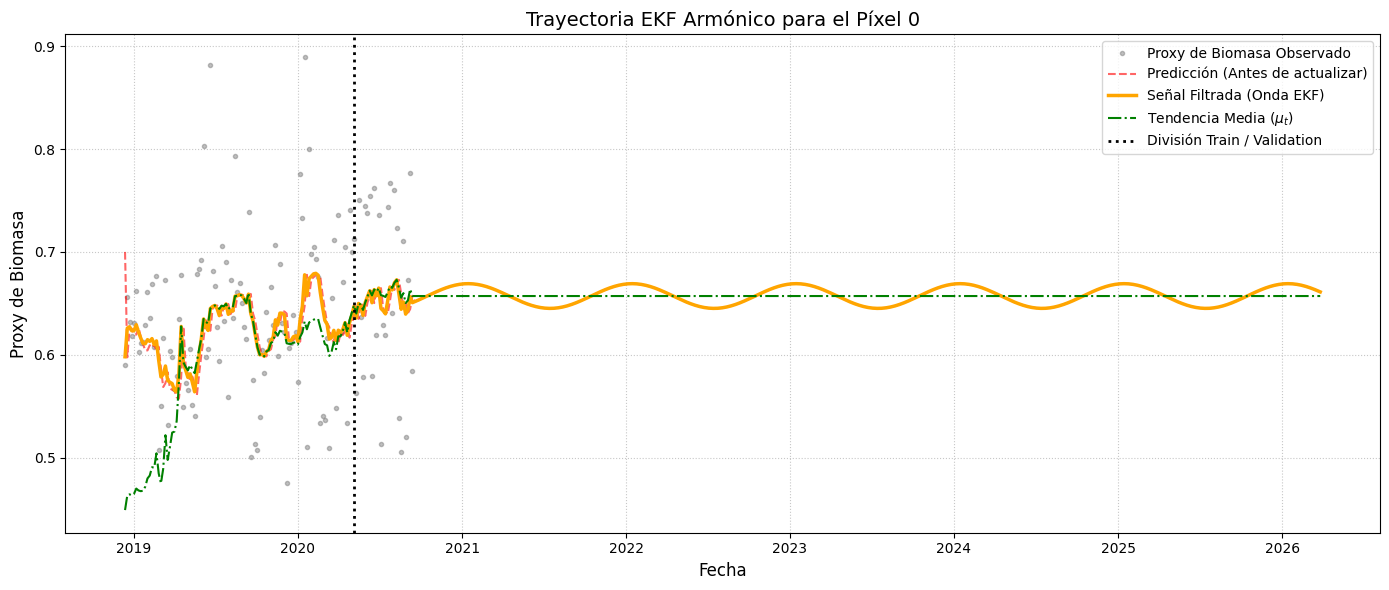

Gráfico del píxel 0 guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/pixel_0_harmonic_trajectory.png


In [ ]:
# =============================================================================
# N. VISUALIZACIÓN DE TRAYECTORIA PARA UN PÍXEL (TRAIN / VALIDATION)
# =============================================================================
import matplotlib.pyplot as plt

# Seleccionar el primer píxel disponible (puedes cambiar el [0] por el ID que quieras revisar)
selected_pixel = ekf_by_pixel["pixel_id"].unique()[0]

# Filtrar el dataframe específicamente para ese píxel
df_plot = ekf_by_pixel[ekf_by_pixel["pixel_id"] == selected_pixel].copy()

plt.figure(figsize=(14, 6))

# 1. Observaciones reales con ruido/nubes (Mostradas como puntos para ver los vacíos)
plt.plot(
    df_plot["date"],
    df_plot["biomass_proxy_observed"],
    label="Proxy de Biomasa Observado",
    alpha=0.5, color="gray", marker=".", linestyle="none"
)

# 2. Predicción a priori (La onda armónica adivinando el futuro un paso adelante)
plt.plot(
    df_plot["date"],
    df_plot["biomass_proxy_predicted"],
    label="Predicción (Antes de actualizar)",
    linestyle="--", color="red", alpha=0.6
)

# 3. Señal filtrada a posteriori (La onda ajustada a la realidad)
plt.plot(
    df_plot["date"],
    df_plot["biomass_proxy_filtered"],
    label="Señal Filtrada (Onda EKF)",
    linewidth=2.5, color="orange"
)

# 4. Tendencia subyacente (Nivel Medio mu_t extraído por el filtro)
plt.plot(
    df_plot["date"],
    df_plot["mu_filtered"],
    label="Tendencia Media ($\mu_t$)",
    linestyle="-.", linewidth=1.5, color="green"
)

# 5. Línea vertical separadora de Entrenamiento vs. Validación
plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    color="black",
    label="División Train / Validation"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Proxy de Biomasa", fontsize=12)
plt.title(f"Trayectoria EKF Armónico para el Píxel {selected_pixel}", fontsize=14)
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la figura en la carpeta Results1
fig_path = PROJECT_DIR / f"pixel_{selected_pixel}_harmonic_trajectory.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico del píxel {selected_pixel} guardado exitosamente en:\n{fig_path}")

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1434/2526666728.py:47: SyntaxWarning: invalid escape sequence '\m'
  label="Tendencia Media ($\mu_t$)",


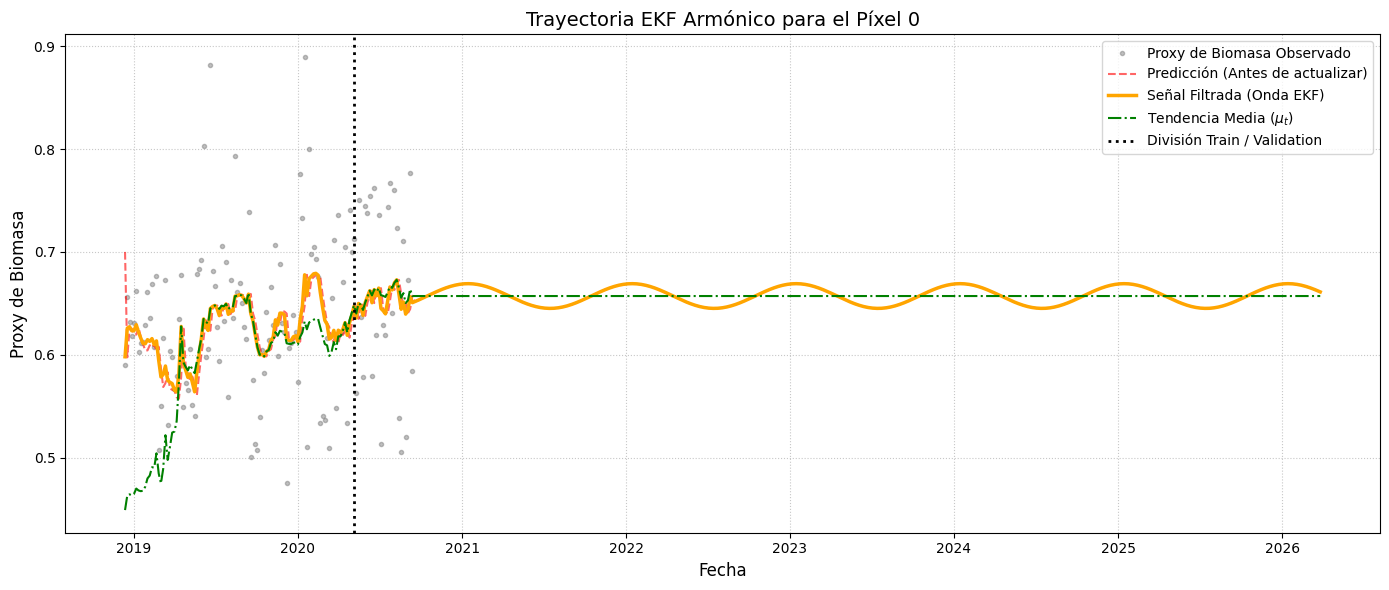

Gráfico guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/pixel_0_harmonic_biomass_trajectory.png


In [ ]:
# =============================================================================
# O. VISUALIZACIÓN DE TRAYECTORIA PARA UN PÍXEL (PROXY DE BIOMASA)
# =============================================================================
import matplotlib.pyplot as plt

# (Asumiendo que selected_pixel y df_plot ya están definidos en la celda anterior,
# si no, puedes descomentar las siguientes dos líneas)
# selected_pixel = ekf_by_pixel["pixel_id"].unique()[0]
# df_plot = ekf_by_pixel[ekf_by_pixel["pixel_id"] == selected_pixel].copy()

plt.figure(figsize=(14, 6))

# 1. Observaciones reales con ruido/nubes
plt.plot(
    df_plot["date"],
    df_plot["biomass_proxy_observed"],
    label="Proxy de Biomasa Observado",
    alpha=0.5,
    color="gray",
    marker=".",
    linestyle="none"
)

# 2. Predicción a priori (La onda armónica adivinando el futuro)
plt.plot(
    df_plot["date"],
    df_plot["biomass_proxy_predicted"],
    label="Predicción (Antes de actualizar)",
    linestyle="--",
    color="red",
    alpha=0.6
)

# 3. Señal filtrada a posteriori (La onda ajustada)
plt.plot(
    df_plot["date"],
    df_plot["biomass_proxy_filtered"],
    label="Señal Filtrada (Onda EKF)",
    linewidth=2.5,
    color="orange"
)

# 4. Tendencia subyacente (Nivel Medio mu_t extraído por el filtro)
plt.plot(
    df_plot["date"],
    df_plot["mu_filtered"],
    label="Tendencia Media ($\mu_t$)",
    linestyle="-.",
    linewidth=1.5,
    color="green"
)

# 5. División Train/Validation
plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    color="black",
    label="División Train / Validation"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Proxy de Biomasa", fontsize=12)
plt.title(f"Trayectoria EKF Armónico para el Píxel {selected_pixel}", fontsize=14)
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la figura en la carpeta Results1
fig_path = PROJECT_DIR / f"pixel_{selected_pixel}_harmonic_biomass_trajectory.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico guardado exitosamente en:\n{fig_path}")

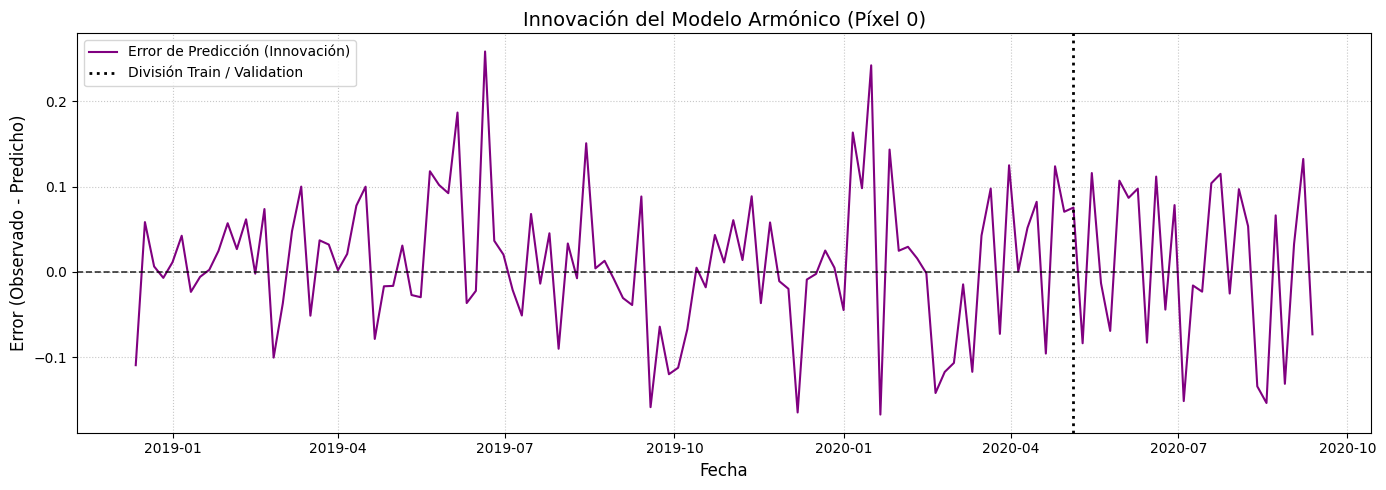

Gráfico de error de predicción guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/pixel_0_harmonic_prediction_error.png


In [ ]:
# =============================================================================
# P. VISUALIZACIÓN DEL ERROR DE PREDICCIÓN (INNOVACIÓN)
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Graficar el error de predicción (Observado - Predicho)
plt.plot(
    df_plot["date"],
    df_plot["error_pred"],
    label="Error de Predicción (Innovación)",
    color="purple",
    linewidth=1.5
)

# 2. Línea base en cero (Representa el modelo perfecto sin error)
plt.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)

# 3. División temporal Train/Validation
plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    color="black",
    label="División Train / Validation"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Error (Observado - Predicho)", fontsize=12)
plt.title(f"Innovación del Modelo Armónico (Píxel {selected_pixel})", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la figura en la carpeta configurada (Results1)
fig_path = PROJECT_DIR / f"pixel_{selected_pixel}_harmonic_prediction_error.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico de error de predicción guardado exitosamente en:\n{fig_path}")

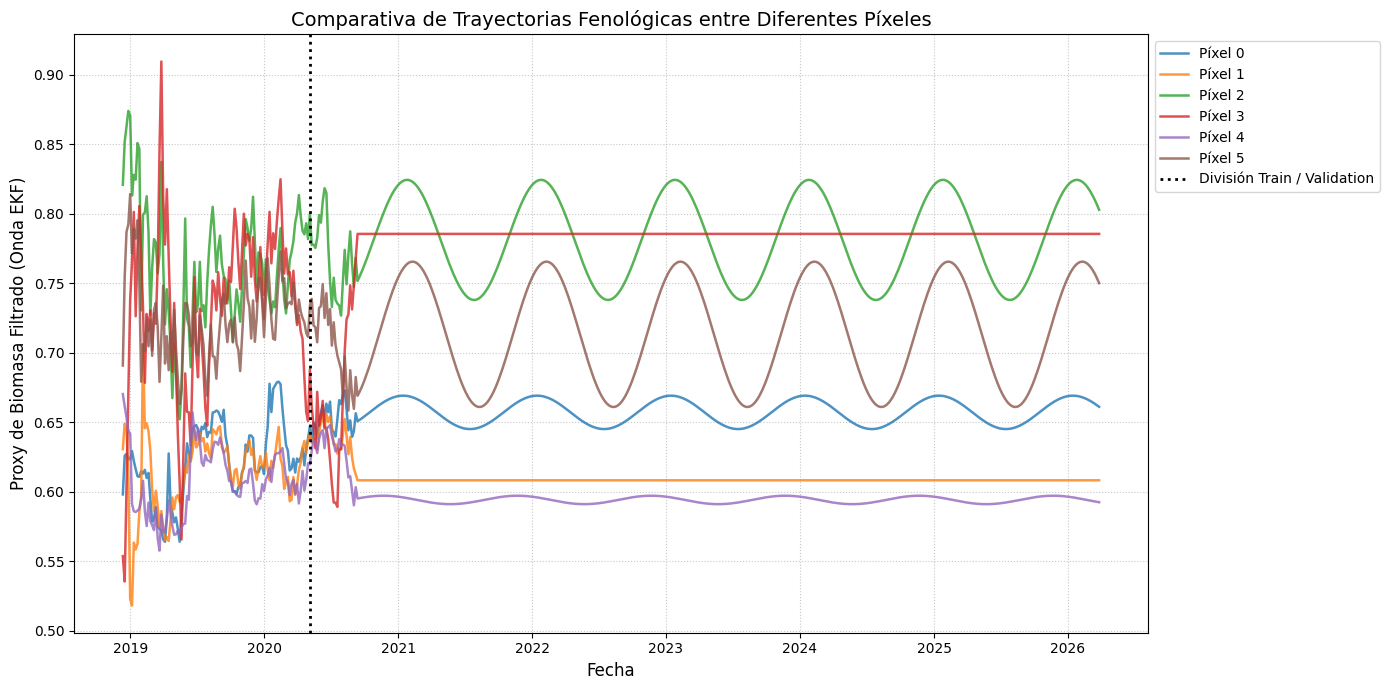

Gráfico comparativo multimuestra guardado en:
/content/Drive/MyDrive/TIMESERIES/Results1/selected_pixels_harmonic_trajectories.png


In [ ]:
# =============================================================================
# Q. VISUALIZACIÓN COMPARATIVA DE MÚLTIPLES PÍXELES (TRAYECTORIAS EKF)
# =============================================================================
import matplotlib.pyplot as plt

# Seleccionar los primeros 6 píxeles únicos para la comparación masiva
selected_pixels = ekf_by_pixel["pixel_id"].unique()[:6]

plt.figure(figsize=(14, 7))

# Iterar sobre cada uno de los píxeles seleccionados y dibujar su onda limpia
for pix in selected_pixels:
    temp = ekf_by_pixel[ekf_by_pixel["pixel_id"] == pix]

    plt.plot(
        temp["date"],
        temp["biomass_proxy_filtered"],  # Visualizamos la señal limpia reconstruida
        label=f"Píxel {pix}",
        linewidth=1.8,
        alpha=0.8
    )

# División temporal de Train / Validation
plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    color="black",
    label="División Train / Validation"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Proxy de Biomasa Filtrado (Onda EKF)", fontsize=12)
plt.title("Comparativa de Trayectorias Fenológicas entre Diferentes Píxeles", fontsize=14)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1)) # Mover leyenda afuera si bloquea líneas
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la gráfica en la carpeta del proyecto
fig_path = PROJECT_DIR / "selected_pixels_harmonic_trajectories.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico comparativo multimuestra guardado en:\n{fig_path}")

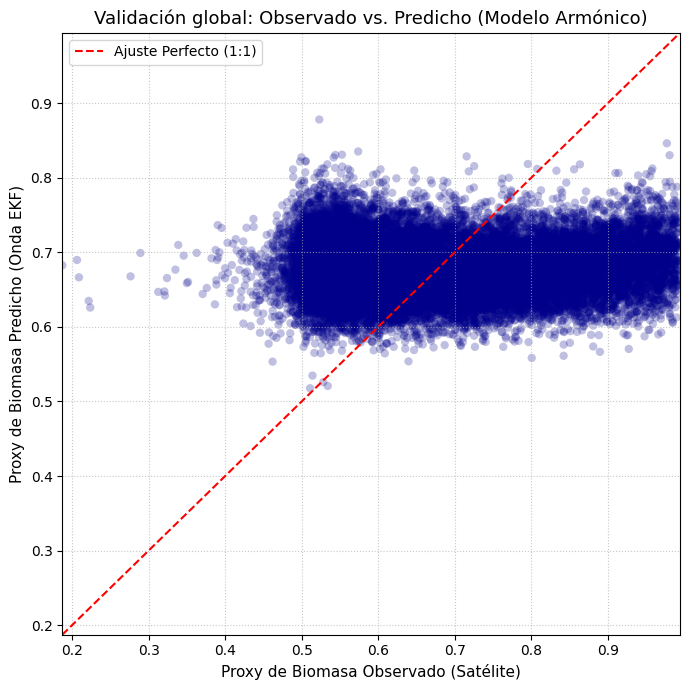

Gráfico de dispersión de validación guardado en:
/content/Drive/MyDrive/TIMESERIES/Results1/validation_observed_vs_predicted_harmonic_biomass.png


In [ ]:
# =============================================================================
# R. GRÁFICO DE VALIDACIÓN: OBSERVADO VS. PREDICHO
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 7))

# Definimos las variables basadas en nuestro proxy de biomasa de validación
x = validation_df["biomass_proxy_observed"]
y = validation_df["biomass_proxy_predicted"]

# Gráfico de dispersión con opacidad (alpha) para identificar zonas de alta densidad de puntos
plt.scatter(x, y, alpha=0.25, color="darkblue", edgecolor="none")

# Calcular límites de forma segura ignorando los NaN para trazar la línea de identidad 1:1
min_val = min(np.nanmin(x), np.nanmin(y))
max_val = max(np.nanmax(x), np.nanmax(y))

# Dibujar la línea diagonal 1:1 (Línea de ajuste perfecto)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1.5, label="Ajuste Perfecto (1:1)")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("Proxy de Biomasa Observado (Satélite)", fontsize=11)
plt.ylabel("Proxy de Biomasa Predicho (Onda EKF)", fontsize=11)
plt.title("Validación global: Observado vs. Predicho (Modelo Armónico)", fontsize=13)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Guardar la figura en Results1
fig_path = PROJECT_DIR / "validation_observed_vs_predicted_harmonic_biomass.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico de dispersión de validación guardado en:\n{fig_path}")

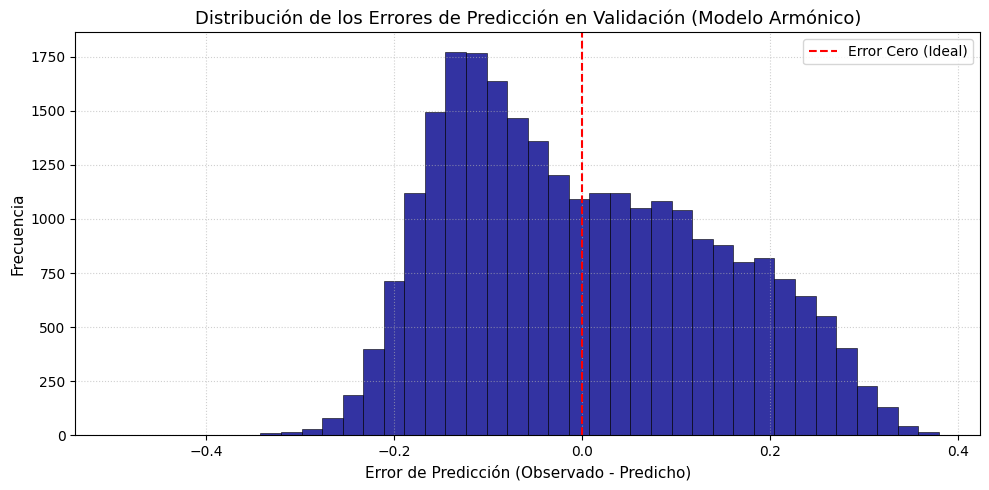

Histograma de errores guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/validation_harmonic_error_histogram.png


In [ ]:
# =============================================================================
# S. HISTOGRAMA DE ERRORES DE VALIDACIÓN (ANÁLISIS DE RESIDUOS)
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Graficar el histograma de los errores de predicción del proxy de biomasa
plt.hist(
    validation_df["error_pred"].dropna(),
    bins=40,
    color="darkblue",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5
)

# Línea de referencia en cero para evaluar visualmente el sesgo (Bias)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Error Cero (Ideal)")

plt.xlabel("Error de Predicción (Observado - Predicho)", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.title("Distribución de los Errores de Predicción en Validación (Modelo Armónico)", fontsize=13)
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Guardar la figura en la carpeta del proyecto (Results1)
fig_path = PROJECT_DIR / "validation_harmonic_error_histogram.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Histograma de errores guardado exitosamente en:\n{fig_path}")

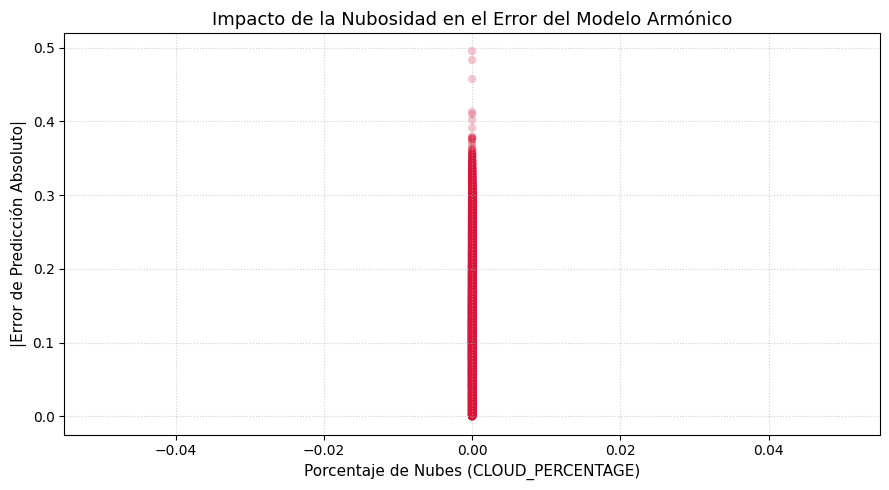

Gráfico de impacto de nubes guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/cloud_percentage_vs_harmonic_error.png


In [ ]:
# =============================================================================
# T. ANÁLISIS DE IMPACTO: PORCENTAJE DE NUBES VS. ERROR DE PREDICCIÓN
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 5))

# Graficar el porcentaje de nubes contra el valor absoluto del error de predicción
plt.scatter(
    validation_df["CLOUD_PERCENTAGE"],
    np.abs(validation_df["error_pred"]),
    alpha=0.25,
    color="crimson",
    edgecolor="none"
)

plt.xlabel("Porcentaje de Nubes (CLOUD_PERCENTAGE)", fontsize=11)
plt.ylabel("|Error de Predicción Absoluto|", fontsize=11)
plt.title("Impacto de la Nubosidad en el Error del Modelo Armónico", fontsize=13)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Guardar la figura en la carpeta del proyecto (Results1)
fig_path = PROJECT_DIR / "cloud_percentage_vs_harmonic_error.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Gráfico de impacto de nubes guardado exitosamente en:\n{fig_path}")

In [ ]:
# =============================================================================
# U. RESUMEN FINAL DEL PIPELINE (EXPORTACIÓN JSON)
# =============================================================================
import json

print("Consolidando metadatos y métricas globales de validación...")

# Construir el diccionario de métricas clave basadas en el modelo armónico
summary = {
    "train_end_date": str(TRAIN_END_DATE),
    "validation_start_date": str(VAL_START_DATE),
    "number_pixels": int(ekf_by_pixel["pixel_id"].nunique()),
    "number_total_rows": int(len(ekf_by_pixel)),
    "number_validation_rows": int(len(validation_df)),

    # Extraemos el RMSE de nuestra variable objetivo principal (biomass_proxy)
    "mean_validation_biomass_proxy_RMSE": float(
        metrics_df.loc[metrics_df["variable"] == "biomass_proxy", "RMSE"].iloc[0]
    ) if "biomass_proxy" in metrics_df["variable"].values else None,

    # Descomenta esta línea si añadiste el NDVI al bloque L de métricas:
    # "mean_validation_NDVI_RMSE": float(metrics_df.loc[metrics_df["variable"] == "NDVI", "RMSE"].iloc[0]) if "NDVI" in metrics_df["variable"].values else None,
}

# Definir la ruta del archivo JSON en Results1
summary_path = PROJECT_DIR / "harmonic_ekf_validation_summary.json"

# Guardar el diccionario con formato indentado para que sea fácilmente legible
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print(f"Resumen ejecutivo JSON guardado exitosamente en:\n{summary_path}\n")

# Desplegar el resumen final en pantalla
summary

Consolidando metadatos y métricas globales de validación...
Resumen ejecutivo JSON guardado exitosamente en:
/content/Drive/MyDrive/TIMESERIES/Results1/harmonic_ekf_validation_summary.json



{'train_end_date': '2020-05-05 00:00:00',
 'validation_start_date': '2020-05-10 00:00:00',
 'number_pixels': 1000,
 'number_total_rows': 534000,
 'number_validation_rows': 431000,
 'mean_validation_biomass_proxy_RMSE': 0.14120270006681324}